# Customer Churn Analysis and Retention Strategy

## Business Problem
Customer churn is a critical challenge for businesses, as acquiring new customers is more expensive than retaining existing ones.
The objective of this project is to analyze customer churn data to identify key factors influencing customer attrition and provide
data-driven recommendations to reduce churn and improve customer retention.

## Business Objectives
- Identify patterns associated with customer churn  
- Compare churned vs non-churned customers  
- Discover high-risk customer segments  
- Suggest actionable retention strategies  


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
print("✅ Libraries Imported")

✅ Libraries Imported


In [58]:
try:
    df = pd.read_csv("data/customer_churn.csv")
    print("Data Loaded Successfully")
except FileNotFoundError:
    print("Error: File not found.")

df.head()

Data Loaded Successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [59]:
df.shape, df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [60]:
# Check missing values
df.isnull().sum()
# Fill missing numeric values with mean
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()
# Data Cleaning Complete

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [61]:
df["Churn"].value_counts()

Churn
0    447
1     53
Name: count, dtype: int64

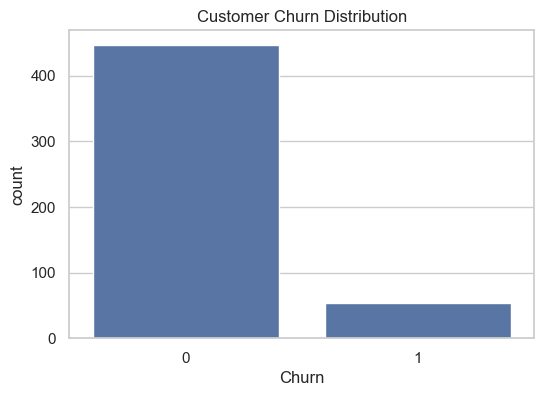

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()


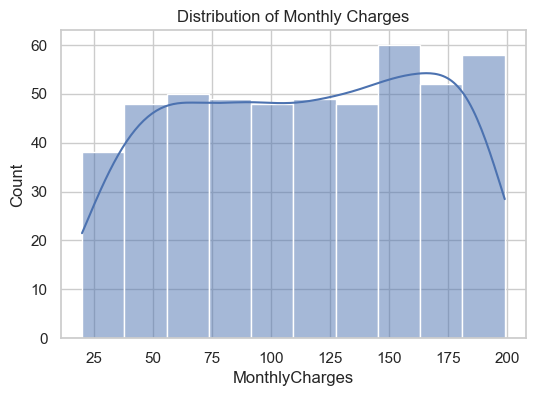

In [63]:
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()


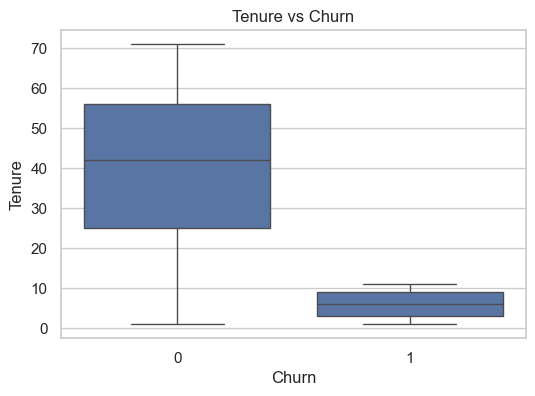

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()


In [65]:
df.groupby("Churn")[["MonthlyCharges", "Tenure"]].mean()
df.groupby("Churn")[["MonthlyCharges", "Tenure"]].std()

,MonthlyCharges,Tenure
Churn,,
0,52.130132,18.783141
1,46.298630,3.162278


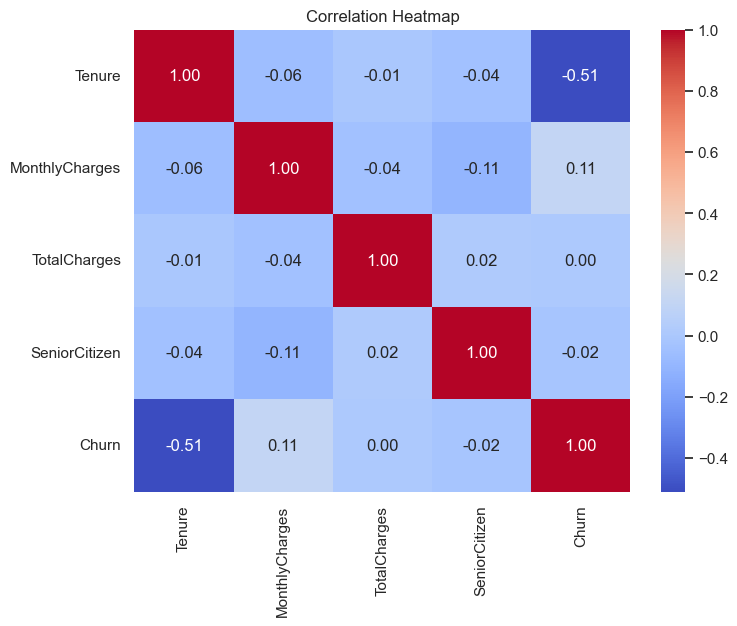

In [66]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [67]:
# Split data using correct churn labels (0 = No, 1 = Yes)
churned = df[df["Churn"] == 1]["MonthlyCharges"]
not_churned = df[df["Churn"] == 0]["MonthlyCharges"]

# Check sample sizes
len(churned), len(not_churned)
print("Churned customers:", len(churned))
print("Non-churned customers:", len(not_churned))

from scipy import stats

t_stat, p_value = stats.ttest_ind(
    churned,
    not_churned,
    equal_var=False  # safer when group sizes differ
)

t_stat, p_value
if p_value < 0.05:
    print("Reject H0 → Significant difference in Monthly Charges")
else:
    print("Fail to reject H0 → No significant difference in Monthly Charges")




Churned customers: 53
Non-churned customers: 447
Reject H0 → Significant difference in Monthly Charges


In [68]:
mean_charge = df["MonthlyCharges"].mean()
std_charge = df["MonthlyCharges"].std()
n = len(df)

margin_error = 1.96 * (std_charge / np.sqrt(n))
(mean_charge - margin_error, mean_charge + margin_error)
print("✅ Statistical Analysis Complete")

✅ Statistical Analysis Complete


## Key Insights
- Customers with higher monthly charges tend to churn more frequently.
- Customers with shorter tenure are at higher risk of churn.
- Month-to-month contracts show higher churn rates.
- Strong correlations exist between service usage and monthly charges.

## Business Recommendations
- Provide discounts or offers to high monthly charge customers.
- Improve onboarding experience for new customers.
- Encourage long-term contracts through incentives.
- Monitor high-risk customers using churn indicators.


## Conclusion
This analysis successfully identified key factors influencing customer churn using statistical and exploratory techniques.
The insights derived can help businesses design effective customer retention strategies and reduce revenue loss.